In [21]:
import json
from sentence_transformers import SentenceTransformer, util
import numpy as np
import seaborn as sns
from scipy import stats
import os
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from sklearn.metrics.pairwise import cosine_distances
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()


# Calculating & plotting

In [15]:
# Load the cosine distances matrix
cos_dist_single = np.load('/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/semantic_diversity/Small/cosine_distances_generation_results_lora_llama_8b_single_v8_embeddings.npy')
cos_dist_multi = np.load('/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/semantic_diversity/Small/cosine_distances_generation_results_lora_llama_8b_multi_v3_embeddings.npy')
cos_dist_human = np.load('/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/semantic_diversity/Small/cosine_distances_generation_results_lora_llama_8b_human_v3_embeddings.npy')
cos_dist_vanilla = np.load('/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/semantic_diversity/Small/cosine_distances_dolly_test_Llama_embeddings.npy')

# Create mask to exclude self-comparisons
mask = np.ones_like(cos_dist_vanilla, dtype=bool)
np.fill_diagonal(mask, False)

# Calculate semantic diversity as the mean of all pairwise cosine distances
sem_div_single = np.mean(cos_dist_single[mask])
sem_div_multi = np.mean(cos_dist_multi[mask])
sem_div_human = np.mean(cos_dist_human[mask])
sem_div_vanilla = np.mean(cos_dist_vanilla[mask])

std_err_vanilla = np.std(cos_dist_vanilla[mask]) / np.sqrt(len(cos_dist_vanilla[mask]))
std_err_single = np.std(cos_dist_single[mask]) / np.sqrt(len(cos_dist_single[mask]))
std_err_multi = np.std(cos_dist_multi[mask]) / np.sqrt(len(cos_dist_multi[mask]))
std_err_human = np.std(cos_dist_human[mask]) / np.sqrt(len(cos_dist_human[mask]))

In [28]:
var_single = np.var(cos_dist_single[mask])
var_multi = np.var(cos_dist_multi[mask])
var_human = np.var(cos_dist_human[mask])
var_vanilla = np.var(cos_dist_vanilla[mask])

print(f"Variance single-source: {var_single:.4f}")
print(f"Variance multi-source: {var_multi:.4f}")
print(f"Variance human-source: {var_human:.4f}")
print(f"Variance vanilla: {var_vanilla:.4f}")

Variance single-source: 0.0077
Variance multi-source: 0.0078
Variance human-source: 0.0077
Variance vanilla: 0.0076


In [19]:
print(f"Semantic diversity score single-source: {sem_div_single:.4f} ± {std_err_single:.6f}")
print(f"Semantic diversity score multi-source: {sem_div_multi:.4f} ± {std_err_multi:.6f}")
print(f"Semantic diversity score human-source: {sem_div_human:.4f} ± {std_err_human:.6f}")
print(f"Semantic diversity score vanilla: {sem_div_vanilla:.4f} ± {std_err_vanilla:.6f}")

Semantic diversity score single-source: 0.9542 ± 0.000013
Semantic diversity score multi-source: 0.9520 ± 0.000013
Semantic diversity score human-source: 0.9543 ± 0.000013
Semantic diversity score vanilla: 0.9553 ± 0.000012


In [24]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [cos_dist_single[mask], cos_dist_multi[mask], cos_dist_human[mask], cos_dist_vanilla[mask]]
dataset_names = ["Single-Source", "Multi-Source", "Human-Source", "None (Vanilla)"]

H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {float(H):.2f}")
print(f"p-value: {float(p_value):.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
            print(f"U-statistic: {float(stat):.2f}")
            print(f"p-value: {float(p):.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 38751.89
p-value: 0.00e+00

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

Single-Source vs Multi-Source:
U-statistic: 1217580895969404.00
p-value: 0.00e+00
Significant difference: Yes

Single-Source vs Human-Source:
U-statistic: 1198287977535420.00
p-value: 1.18e-40
Significant difference: Yes

Single-Source vs None (Vanilla):
U-statistic: 1191008410841712.00
p-value: 0.00e+00
Significant difference: Yes

Multi-Source vs Human-Source:
U-statistic: 1180906054841442.00
p-value: 0.00e+00
Significant difference: Yes

Multi-Source vs None (Vanilla):
U-statistic: 1173606320086278.00
p-value: 0.00e+00
Significant difference: Yes

Human-Source vs None (Vanilla):
U-statistic: 1192895103745198.00
p-value: 0.00e+00
Significant difference: Yes


In [27]:
# Sample a reasonable number of distances for statistical testing
np.random.seed(42)
n_sample = 10000  # Still large but manageable

sampled_groups = []
for cos_dist in [cos_dist_single, cos_dist_multi, cos_dist_human, cos_dist_vanilla]:
    distances = cos_dist[mask]
    sampled_distances = np.random.choice(distances, size=n_sample, replace=False)
    sampled_groups.append(sampled_distances)

H, p_value = stats.kruskal(*sampled_groups)
print(f"H-statistic (sampled): {float(H):.2f}")
print(f"p-value (sampled): {float(p_value):.4f}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            stat, p = stats.mannwhitneyu(sampled_groups[i], sampled_groups[j], alternative='two-sided')
            print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
            print(f"U-statistic: {float(stat):.2f}")
            print(f"p-value: {float(p):.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


H-statistic (sampled): 20.42
p-value (sampled): 0.0001

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

Single-Source vs Multi-Source:
U-statistic: 51000429.00
p-value: 1.43e-02
Significant difference: No

Single-Source vs Human-Source:
U-statistic: 49595904.00
p-value: 3.22e-01
Significant difference: No

Single-Source vs None (Vanilla):
U-statistic: 49256118.00
p-value: 6.84e-02
Significant difference: No

Multi-Source vs Human-Source:
U-statistic: 48599195.00
p-value: 6.01e-04
Significant difference: Yes

Multi-Source vs None (Vanilla):
U-statistic: 48265263.00
p-value: 2.15e-05
Significant difference: Yes

Human-Source vs None (Vanilla):
U-statistic: 49657415.00
p-value: 4.01e-01
Significant difference: No


# Calculating semantic diversity

## Loading sBERT embeddings

In [10]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2") 

def load_embeddings(path):
    embeddings_dict = {
        'sentences': [],
        'embeddings': []
    }
    
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            embeddings_dict['sentences'].append(data['sentence'])
            embeddings_dict['embeddings'].append(np.array(data['embedding']))
            
    # Convert list of embeddings to a numpy array
    embeddings_dict['embeddings'] = np.array(embeddings_dict['embeddings'])
    return embeddings_dict


sbert_embeddings = {
    "Small":{
        "Single-source-tuned": load_embeddings("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/sentence_embeddings/Small/generation_results_lora_llama_8b_single_v8_embeddings.jsonl"),
        "Multi-source-tuned": load_embeddings("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/sentence_embeddings/Small/generation_results_lora_llama_8b_multi_v3_embeddings.jsonl"),
        "Human-tuned": load_embeddings("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/sentence_embeddings/Small/generation_results_lora_llama_8b_human_v3_embeddings.jsonl"),
        "Vanilla": load_embeddings("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/data/sentence_embeddings/Small/dolly_test_Llama_embeddings.jsonl")
    }
}


## Calculating cosine distances, semantic diversity, and saving to files in Data/analysis/semantic_diversity

In [11]:
def calculate_semantic_diversity(embeddings):
    """Calculate semantic diversity from embeddings."""
    # Calculate cosine similarities
    similarities = util.pytorch_cos_sim(embeddings, embeddings).numpy()
    
    # Convert to cosine distances
    cosine_distances = 1 - similarities
    
    # Create mask to exclude self-comparisons
    mask = np.ones_like(cosine_distances, dtype=bool)
    np.fill_diagonal(mask, False)
    
    # Calculate semantic diversity (average pairwise cosine distance)
    div_sem = np.mean(cosine_distances[mask])
    
    return cosine_distances, div_sem


def process_embeddings_directory(input_dir, output_dir):
    """Process all embedding files in a directory and save results."""
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize list to store results
    results = []
    
    # Process each .jsonl file in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith('.jsonl'):
            # Load embeddings from jsonl file
            embeddings_path = os.path.join(input_dir, filename)
            embeddings_data = []
            
            with open(embeddings_path, 'r') as f:
                for line in f:
                    item = json.loads(line)
                    embeddings_data.append(item['embedding'])
            
            # Convert to numpy array
            embeddings = np.array(embeddings_data)
            
            # Calculate distances and diversity
            cosine_distances, div_sem = calculate_semantic_diversity(embeddings)
            
            # Create output filename for distances
            base_name = os.path.splitext(filename)[0]
            distances_filename = f"cosine_distances_{base_name}.npy"
            
            # Save distances
            np.save(os.path.join(output_dir, distances_filename), cosine_distances)
            
            # Add result to list
            results.append({
                'filename': base_name,
                'semantic_diversity': div_sem
            })
            
            print(f"Processed {filename}")
            print(f"Semantic Diversity: {div_sem}")
    
    # Create DataFrame from results
    results_df = pd.DataFrame(results)
    
    # Save results to CSV
    results_df.to_csv(os.path.join(output_dir, 'semantic_diversity_results.csv'), index=False)

def main():
    # Define base directories
    base_input_dir = "/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/sentence_embeddings"
    base_output_dir = "/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/semantic_diversity"
    
    # Process each category
    categories = ['Small']
    
    for category in categories:
        input_dir = os.path.join(base_input_dir, category)
        output_dir = os.path.join(base_output_dir, category)
        
        print(f"\nProcessing {category} embeddings...")
        process_embeddings_directory(input_dir, output_dir)

if __name__ == "__main__":
    main()


Processing Small embeddings...
Processed dolly_test_Llama_embeddings.jsonl
Semantic Diversity: 0.9552743886467076
Processed generation_results_lora_llama_8b_single_v8_embeddings.jsonl
Semantic Diversity: 0.9541993517713516
Processed generation_results_lora_llama_8b_multi_v3_embeddings.jsonl
Semantic Diversity: 0.952031186293427
Processed generation_results_lora_llama_8b_human_v3_embeddings.jsonl
Semantic Diversity: 0.9542558379781172


## Calculating std err

In [12]:
# Calculating standard error

def calculate_standard_error(cosine_distances):
    """Calculate standard error from cosine distances."""
    # Create mask to exclude self-comparisons
    mask = np.ones_like(cosine_distances, dtype=bool)
    np.fill_diagonal(mask, False)

    std_dev = np.std(cosine_distances[mask], ddof=1)
    n = len(cosine_distances[mask])
    std_error = std_dev / np.sqrt(n)
    
    return std_error
    

### Standard error for individual datasets

In [13]:
semantic_diversity_scores = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/semantic_diversity/Small/semantic_diversity_results.csv")

# Add a standard error column to the semantic_diversity_scores dataframe
semantic_diversity_scores['standard_error'] = None

# Define the base directory for the cosine distance files
base_dir = "/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/semantic_diversity"

# Iterate through each row in the dataframe
for idx, row in semantic_diversity_scores.iterrows():
    # Construct the path to the corresponding cosine distances file
    filename = row['filename']
    sem_div_score = row['semantic_diversity']


    # Prepare for plotting
    labels = df['label'].tolist()
    values = df['semantic diversity'].tolist()
    errors = df['standard_error'].tolist()
    
    if os.path.exists(file_path):
        try:
            # Load the cosine distances and calculate the standard error
            cosine_distances = np.load(file_path)
            std_error = calculate_standard_error(cosine_distances)
            
            # Update the dataframe with the calculated standard error
            semantic_diversity_scores.at[idx, 'standard_error'] = std_error
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    else:
        print(f"Warning: File not found: {file_path}")

# Display the updated dataframe with standard errors
semantic_diversity_scores.to_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all.csv", index=False)
semantic_diversity_scores.head(25)

NameError: name 'df' is not defined

### Averaging semantic diversity scores and standard error over datasets

In [9]:
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all.csv")

# Define the base directory for the cosine distance files
base_dir = "../../Data/analysis/semantic_diversity"

# Initialize a dictionary to store cosine distances for each category
cosine_distances_by_category = {
    "Human": [],
    "Small": [],
    "Medium": [],
    "Large": []
}

# Initialize dictionaries to store Llama-specific cosine distances for each category
llama_cosine_distances_by_category = {
    "Small": [],
    "Medium": [],
    "Large": []
}

# Iterate through each row in the dataframe
for idx, row in semantic_diversity_scores.iterrows():
    # Construct the path to the corresponding cosine distances file
    category = row['size']
    dataset = row['dataset']
    model = row['model']

    
    
    # Handle the "Human" case differently as it doesn't have a model name in the filename
    if category == "Human":
        file_name = f"cosine_distances_{dataset}_human_embeddings.npy"
    else:
        file_name = f"cosine_distances_{dataset}_{model}_embeddings.npy"
    
    file_path = os.path.join(base_dir, category, file_name)
    
    # Check if the file exists
    if os.path.exists(file_path):
        try:
            # Load the cosine distances 
            cosine_distances = np.load(file_path)
            cosine_distances_by_category[category].append(cosine_distances)
            
            # If this is a Llama model, also add to the Llama-specific dictionary
            if model == "Llama" and category in ["Small", "Medium", "Large"]:
                llama_cosine_distances_by_category[category].append(cosine_distances)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    else:
        print(f"Warning: File not found: {file_path}")

# Function to calculate mean semantic diversity and standard error
def calculate_mean_and_standard_error(distances):
    all_distances = np.concatenate(distances)
    mean_diversity = np.mean(all_distances)
    standard_error = np.std(all_distances) / np.sqrt(len(all_distances))
    return mean_diversity, standard_error

# Calculate the mean semantic diversity and standard error for each category and add to dataframe
for category, distances in cosine_distances_by_category.items():
    if distances:
        mean_diversity, standard_error = calculate_mean_and_standard_error(distances)
        print(f"Category: {category}")
        print(f"Mean Semantic Diversity: {mean_diversity}")
        print(f"Standard Error: {standard_error}\n")
        
        # Add a new row to the dataframe for the category average
        new_row = {
            'dataset': 'all',
            'size': category,
            'model': 'average',
            'semantic diversity': mean_diversity,
            'standard_error': standard_error
        }
        semantic_diversity_scores = pd.concat([semantic_diversity_scores, pd.DataFrame([new_row])], ignore_index=True)
    else:
        print(f"No data available for category: {category}\n")

# Calculate the mean semantic diversity and standard error for Llama models in each category
for category, distances in llama_cosine_distances_by_category.items():
    if distances:
        mean_diversity, standard_error = calculate_mean_and_standard_error(distances)
        print(f"Llama Category: {category}")
        print(f"Mean Semantic Diversity: {mean_diversity}")
        print(f"Standard Error: {standard_error}\n")
        
        # Add a new row to the dataframe for the Llama category average
        new_row = {
            'dataset': 'all',
            'size': category,
            'model': 'Llama-average',
            'semantic diversity': mean_diversity,
            'standard_error': standard_error
        }
        semantic_diversity_scores = pd.concat([semantic_diversity_scores, pd.DataFrame([new_row])], ignore_index=True)
    else:
        print(f"No Llama data available for category: {category}\n")

# Display the updated dataframe with standard errors
# semantic_diversity_scores.to_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all_with_averages.csv", index=False)
semantic_diversity_scores.head(30)

Category: Human
Mean Semantic Diversity: 0.9713236411918892
Standard Error: 0.0004951122201080557

Category: Small
Mean Semantic Diversity: 0.9532787539182457
Standard Error: 0.0004001826538484095

Category: Medium
Mean Semantic Diversity: 0.9538645934094658
Standard Error: 0.00039976481967805567

Category: Large
Mean Semantic Diversity: 0.9498597268456069
Standard Error: 0.0004038548700893419

Llama Category: Small
Mean Semantic Diversity: 0.9565477746505882
Standard Error: 0.0005225150656398891

Llama Category: Medium
Mean Semantic Diversity: 0.9539970910753436
Standard Error: 0.0005279130937907288

Llama Category: Large
Mean Semantic Diversity: 0.9536637644853905
Standard Error: 0.0005275213906265998



,dataset,size,model,semantic diversity,standard_error
0,dolly_train_1,Human,Human,0.971391,0.000012
1,dolly_train_2,Human,Human,0.971526,0.000012
2,dolly_train_3,Human,Human,0.971009,0.000012
3,dolly_train_4,Human,Human,0.971923,0.000012
4,dolly_train_1,Small,Llama,0.957039,0.000012
5,dolly_train_2,Small,Llama,0.957276,0.000012
6,dolly_train_3,Small,Llama,0.956871,0.000012
7,dolly_train_4,Small,Llama,0.955551,0.000012
8,dolly_train_2,Small,Gemma,0.935083,0.000013
9,dolly_train_3,Small,Qwen,0.951034,0.000013


In [11]:
semantic_diversity_scores.to_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all_with_averages.csv", index=False)

# Plotting

## Plotting semantic diversity scores on bar charts

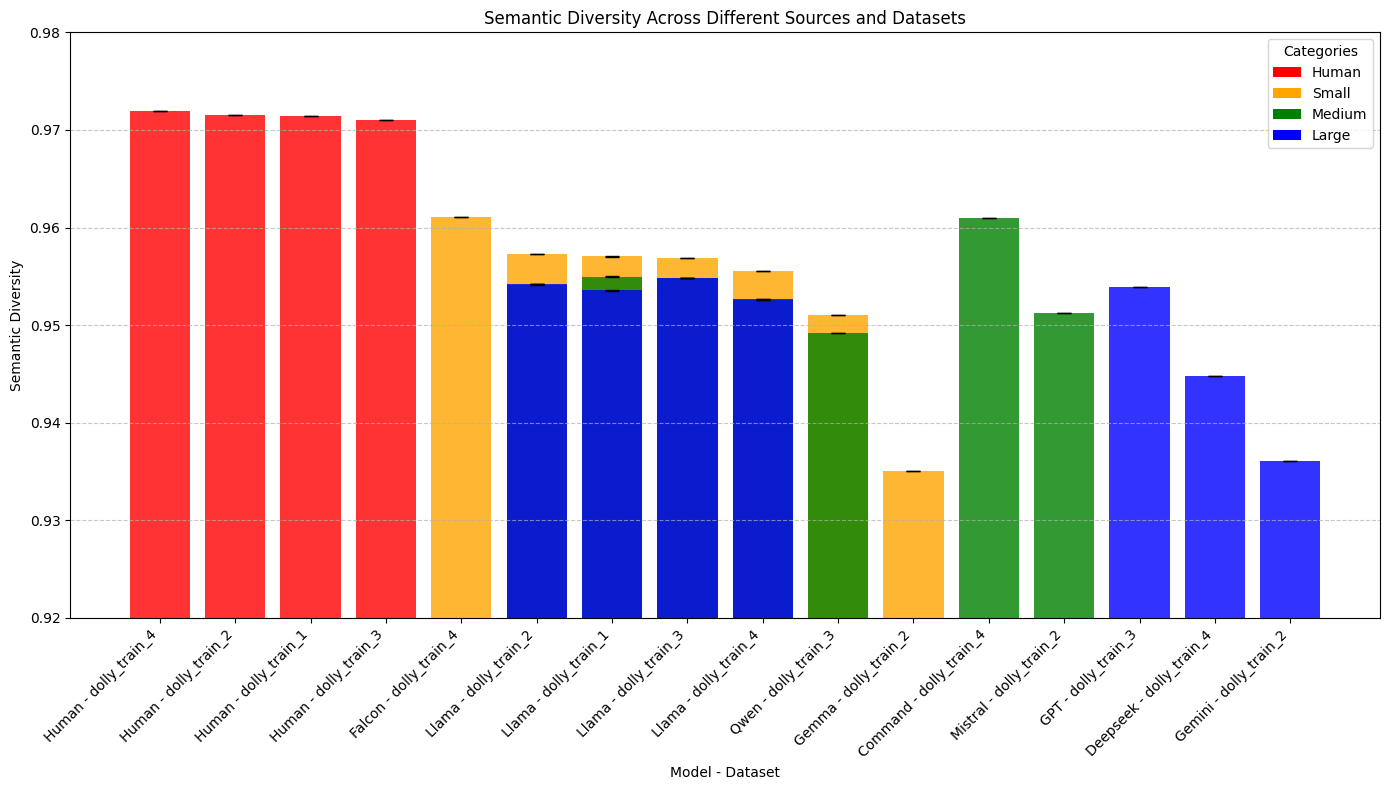

In [ ]:
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all.csv")

def plot_semantic_diversity(semantic_diversity_scores):
    # Use the semantic_diversity_scores dataframe that's already loaded
    # Create a copy to avoid modifying the original
    df = semantic_diversity_scores.copy()
    
    # Create a new column for the category-dataset-model label
    df['label'] = df.apply(lambda row: f"{row['size']} - {row['dataset']} - {row['model']}", axis=1)
    
    # Define category order for sorting
    categories = ["Human", "Small", "Medium", "Large"]
    category_order = {cat: idx for idx, cat in enumerate(categories)}
    
    # Sort by category first, then by semantic diversity value (descending)
    df['category_order'] = df['size'].map(category_order)
    df = df.sort_values(by=['category_order', 'semantic diversity'], ascending=[True, False])
    
    # Prepare for plotting
    labels = df['label'].tolist()
    values = df['semantic diversity'].tolist()
    errors = df['standard_error'].tolist()
    
    # Create color mapping for categories
    category_colors = {
        'Human': 'red',
        'Small': 'orange',
        'Medium': 'green',
        'Large': 'blue'
    }
    
    # Assign colors based on category
    colors = [category_colors.get(label.split(' - ')[0], 'gray') for label in labels]
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bars = plt.bar(labels, values, color=colors, yerr=errors, capsize=5, ecolor='black', alpha=0.8)
    
    # Add labels and title
    plt.xlabel('Dataset - Source')
    plt.ylabel('Semantic Diversity')
    plt.title('Semantic Diversity Across Different Sources and Datasets')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Add a grid for easier reading
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis lower limit to 0.92, top to 0.98
    plt.ylim(bottom=0.92, top=0.98)
    
    # Adjust layout
    plt.tight_layout()
    
    # Add a legend
    
    legend_elements = [Patch(facecolor=color, label=cat) 
                      for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements, title='Categories')
    
    # Show the plot
    plt.show()

# Run the plotting function
plot_semantic_diversity(semantic_diversity_scores)


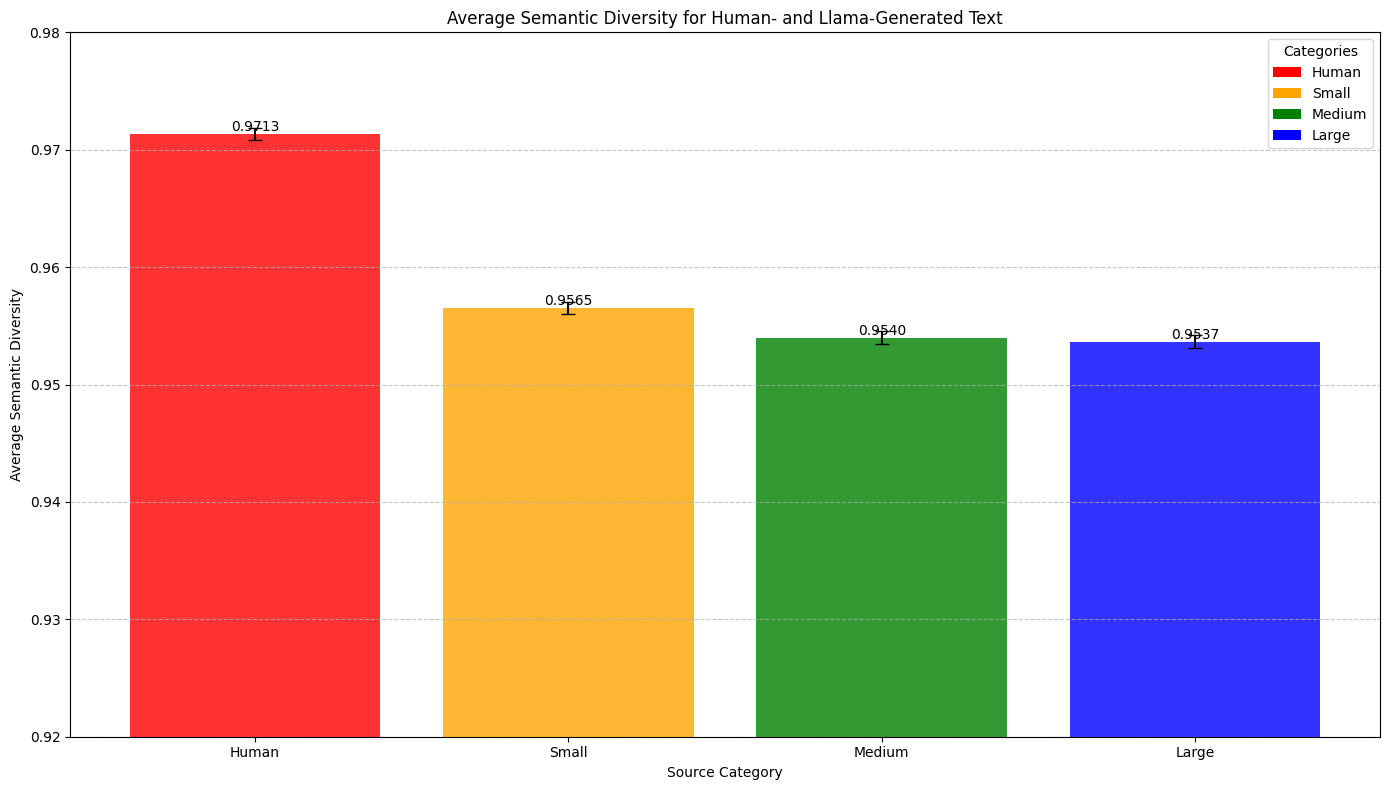

In [13]:
def plot_semantic_diversity(df):
    # Get the human average row
    human_avg_row = df[(df['model'] == 'average') & (df['size'] == 'Human')]
    # Filter for rows that contain 'Llama-average' in the model column
    llama_avg_df = df[df['model'] == 'Llama-average']
    # Concatenate with human row first, then Llama averages
    avg_df = pd.concat([human_avg_row, llama_avg_df])
    
    # Prepare for plotting
    labels = avg_df['size'].tolist()
    values = avg_df['semantic diversity'].tolist()
    errors = avg_df['standard_error'].tolist()
    
    # Create color mapping for categories
    category_colors = {
        'Human': 'red',
        'Small': 'orange',
        'Medium': 'green',
        'Large': 'blue'
    }
    
    # Assign colors based on category
    colors = [category_colors.get(label, 'gray') for label in labels]
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bars = plt.bar(labels, values, color=colors, yerr=errors, capsize=5, ecolor='black', alpha=0.8)
    
    # Add labels and title
    plt.xlabel('Source Category')
    plt.ylabel('Average Semantic Diversity')
    plt.title('Average Semantic Diversity for Human- and Llama-Generated Text')
    
    # Add a grid for easier reading
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis limits
    plt.ylim(bottom=0.92, top=0.98)
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Add a legend
    legend_elements = [Patch(facecolor=color, label=cat) 
                      for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements, title='Categories')
    
    # Show the plot
    plt.show()

# Run the plotting function
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all_with_averages.csv")
plot_semantic_diversity(semantic_diversity_scores)


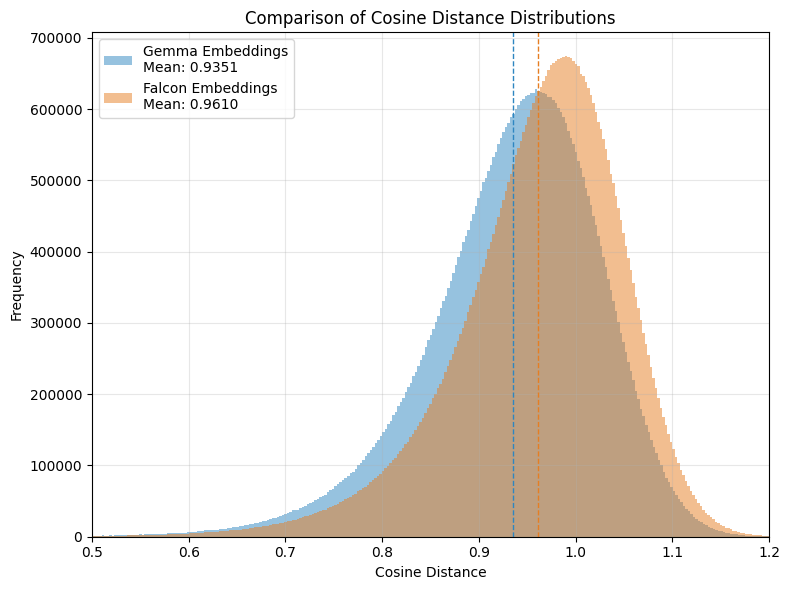

In [16]:
def plot_overlaid_cosine_distance_histograms(file_paths, labels, colors=['#A1C9F4', '#FFB4B4'], alpha=0.5):
    """
    Plot overlaid histograms of cosine distances from multiple numpy files.
    
    Args:
        file_paths: List of paths to the .npy files containing the cosine distance matrices
        labels: List of labels for each distribution
        colors: List of colors for each histogram
        alpha: Transparency level for the histograms
    """
    plt.figure(figsize=(8, 6))
    
    for file_path, label, color in zip(file_paths, labels, colors):
        # Load the cosine distance matrix
        cosine_distances = np.load(file_path)
        
        # Flatten the matrix to get all pairwise distances
        # Exclude the diagonal (self-comparisons) which are always 0
        mask = ~np.eye(cosine_distances.shape[0], dtype=bool)
        distances = cosine_distances[mask]
        
        # Calculate mean
        mean_distance = np.mean(distances)
        
        # Create the histogram
        plt.hist(distances, bins=500, alpha=alpha, color=color, label=f'{label}\nMean: {mean_distance:.4f}')
        
        # Add a vertical line for the mean
        plt.axvline(mean_distance, color=color, linestyle='dashed', linewidth=1)
    
    # Add labels and title
    plt.xlabel('Cosine Distance')
    plt.ylabel('Frequency')
    plt.title('Comparison of Cosine Distance Distributions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0.5, 1.2)  
    plt.tight_layout()
    plt.show()

# Example usage:
file_paths = [
    "../../Data/analysis/semantic_diversity/Small/cosine_distances_dolly_train_2_Gemma_embeddings.npy",
    #"../../Data/analysis/semantic_diversity/Human/cosine_distances_dolly_train_2_human_embeddings.npy"
    "../../Data/analysis/semantic_diversity/Small/cosine_distances_dolly_train_4_Falcon_embeddings.npy"
]
labels = ['Gemma Embeddings', 'Human Embeddings']
labels = ['Gemma Embeddings', 'Falcon Embeddings']
colors = ['#2E86C1', '#E67E22']  # Ocean blue and orange
plot_overlaid_cosine_distance_histograms(file_paths, labels, colors)